In [3]:
import os
for root, dirs, files in os.walk(r'D:\Data science Project\EEG Chrononet\EEGdata'):
    for f in files:
        if f == 'features_table.csv':
            print(os.path.join(root, f))
print("Search done")

D:\Data science Project\EEG Chrononet\EEGdata\stats_csv\features_table.csv
Search done


In [1]:
# ── ML Pipeline Notebook ──────────────────────────────────────
# Cell 1 — Setup + load precomputed feature table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

# ── Folders ───────────────────────────────────────────────────
FIG_DIR = r'D:\Data science Project\EEG Chrononet\EEGdata\figures'
CSV_DIR = r'D:\Data science Project\EEG Chrononet\EEGdata\stats_csv'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

mpl.rcParams.update({
    'font.size':14,'font.weight':'bold','axes.titlesize':16,
    'axes.titleweight':'bold','axes.labelsize':14,'axes.labelweight':'bold',
    'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12,
    'axes.spines.top':False,'axes.spines.right':False,
})
def save_fig(fname, dpi=300):
    p = os.path.join(FIG_DIR, fname)
    plt.savefig(p, dpi=dpi, bbox_inches='tight'); print(f"Saved: {p}")

# ── Load feature table from stats notebook ────────────────────
df = pd.read_csv(r'D:\Data science Project\EEG Chrononet\EEGdata\stats_csv\features_table.csv')
print(f"Loaded feature table: {df.shape}")
print(f"Subjects: {df['subj'].nunique()}, "
      f"Conditions: {list(df['cond'].unique())}, "
      f"Bands: {list(df['band'].unique())}")

BAND_NAMES = ['delta','theta','alpha','beta','gamma']
FEATURES   = ['band_power','mean_conn','clustering','strength','small_world']

# ── Build subject-level feature matrix per condition ──────────
def build_matrix(cond, feature_set=None):
    """
    Returns X (subjects x features), y (1=IDD), subject IDs, feature names.
    feature_set: list of features to include, or None for all.
    """
    if feature_set is None:
        feature_set = FEATURES

    sub = df[df['cond']==cond].copy()
    pivot = sub.pivot_table(index=['subj','group'],
                            columns='band',
                            values=feature_set)
    pivot.columns = [f'{feat}_{band}' for feat, band in pivot.columns]
    pivot = pivot.reset_index()

    feat_cols = [c for c in pivot.columns if c not in ['subj','group']]
    X = pivot[feat_cols].fillna(pivot[feat_cols].median()).values
    y = (pivot['group']=='IDD').astype(int).values
    return X, y, pivot['subj'].values, feat_cols

# Test build
X, y, subjs, fnames = build_matrix('Rest')
print(f"\nRest matrix: X={X.shape}, y={y.sum()} IDD / {len(y)-y.sum()} TDC")
print(f"Features ({len(fnames)}): {fnames}")

Loaded feature table: (140, 9)
Subjects: 14, Conditions: ['Music', 'Rest'], Bands: ['delta', 'theta', 'alpha', 'beta', 'gamma']

Rest matrix: X=(14, 25), y=7 IDD / 7 TDC
Features (25): ['band_power_alpha', 'band_power_beta', 'band_power_delta', 'band_power_gamma', 'band_power_theta', 'clustering_alpha', 'clustering_beta', 'clustering_delta', 'clustering_gamma', 'clustering_theta', 'mean_conn_alpha', 'mean_conn_beta', 'mean_conn_delta', 'mean_conn_gamma', 'mean_conn_theta', 'small_world_alpha', 'small_world_beta', 'small_world_delta', 'small_world_gamma', 'small_world_theta', 'strength_alpha', 'strength_beta', 'strength_delta', 'strength_gamma', 'strength_theta']


In [7]:
# Cell 2 — LOSO cross-validation: compare 3 classifiers per condition

def run_loso(X, y, clf_factory):
    """
    Leave-one-subject-out CV with in-fold scaling.
    clf_factory: function returning a fresh classifier.
    Returns: auc, balanced_acc, y_true, y_pred, y_score
    """
    loo = LeaveOneOut()
    y_true, y_pred, y_score = [], [], []

    for tr, te in loo.split(X):
        scaler = StandardScaler().fit(X[tr])
        Xtr = scaler.transform(X[tr])
        Xte = scaler.transform(X[te])

        clf = clf_factory()
        clf.fit(Xtr, y[tr])

        pred = clf.predict(Xte)[0]
        if hasattr(clf, 'predict_proba'):
            score = clf.predict_proba(Xte)[0, 1]
        else:
            score = clf.decision_function(Xte)[0]

        y_true.append(y[te][0])
        y_pred.append(pred)
        y_score.append(score)

    auc = roc_auc_score(y_true, y_score)
    bacc = balanced_accuracy_score(y_true, y_pred)
    return auc, bacc, np.array(y_true), np.array(y_pred), np.array(y_score)

# Classifier factories
CLASSIFIERS = {
    'LogReg (L2)' : lambda: LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
    'Linear SVM'  : lambda: SVC(kernel='linear', C=1.0, probability=True),
    'RandomForest': lambda: RandomForestClassifier(n_estimators=200,
                                                    max_depth=3,
                                                    random_state=42),
}

print("LOSO cross-validation results:\n")
print(f"{'Condition':<10} {'Classifier':<14} {'AUC':>7} {'Bal.Acc':>9}")
print("-" * 44)

ml_results = []
for cond in ['Rest','Music']:
    X, y, subjs, fnames = build_matrix(cond)
    for clf_name, factory in CLASSIFIERS.items():
        auc, bacc, yt, yp, ys = run_loso(X, y, factory)
        ml_results.append({
            'cond':cond, 'classifier':clf_name,
            'AUC':auc, 'balanced_acc':bacc,
        })
        print(f"{cond:<10} {clf_name:<14} {auc:>7.3f} {bacc:>9.3f}")
    print()

ml_df = pd.DataFrame(ml_results)
ml_df.to_csv(os.path.join(CSV_DIR, 'ml_model_comparison.csv'), index=False)
print(f"Saved ml_model_comparison.csv")

LOSO cross-validation results:

Condition  Classifier         AUC   Bal.Acc
--------------------------------------------
Rest       LogReg (L2)      0.878     0.786
Rest       Linear SVM       0.796     0.714
Rest       RandomForest     0.878     0.857

Music      LogReg (L2)      0.776     0.786
Music      Linear SVM       0.694     0.714
Music      RandomForest     0.939     0.929

Saved ml_model_comparison.csv


In [9]:
# Cell 3 — SHAP explainability on RandomForest (best model)

import shap

print(f"SHAP version: {shap.__version__}\n")

shap_data = {}  # cond -> dict with shap_values, X, fnames

for cond in ['Rest','Music']:
    X, y, subjs, fnames = build_matrix(cond)

    # Scale (fit on all data — for SHAP interpretation, not for performance estimate)
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)

    # Fit RF on full data for explanation
    rf = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42)
    rf.fit(Xs, y)

    # TreeSHAP
    explainer   = shap.TreeExplainer(rf)
    shap_vals   = explainer.shap_values(Xs)

    # For binary classification, shap_values may be a list [class0, class1]
    # or a 3D array. Extract class 1 (IDD) contributions.
    if isinstance(shap_vals, list):
        sv = shap_vals[1]
    elif shap_vals.ndim == 3:
        sv = shap_vals[:, :, 1]
    else:
        sv = shap_vals

    shap_data[cond] = {
        'shap': sv, 'X': Xs, 'X_raw': X,
        'fnames': fnames, 'y': y, 'rf': rf,
    }

    # Mean absolute SHAP per feature
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)[::-1]

    print(f"=== {cond}: Top 10 features by mean |SHAP| ===")
    for rank, idx in enumerate(order[:10], 1):
        print(f"  {rank:2d}. {fnames[idx]:22s}  {mean_abs[idx]:.4f}")
    print()

print("✅ SHAP values computed")

SHAP version: 0.49.1

=== Rest: Top 10 features by mean |SHAP| ===
   1. clustering_beta         0.0491
   2. strength_alpha          0.0459
   3. mean_conn_alpha         0.0433
   4. strength_gamma          0.0400
   5. clustering_gamma        0.0332
   6. mean_conn_beta          0.0291
   7. strength_beta           0.0261
   8. mean_conn_gamma         0.0242
   9. strength_theta          0.0166
  10. band_power_beta         0.0153

=== Music: Top 10 features by mean |SHAP| ===
   1. clustering_beta         0.0874
   2. mean_conn_beta          0.0717
   3. strength_beta           0.0606
   4. strength_alpha          0.0378
   5. mean_conn_alpha         0.0316
   6. band_power_beta         0.0210
   7. strength_theta          0.0203
   8. mean_conn_theta         0.0194
   9. small_world_beta        0.0156
  10. band_power_gamma        0.0152

✅ SHAP values computed


Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_shap_summary.png


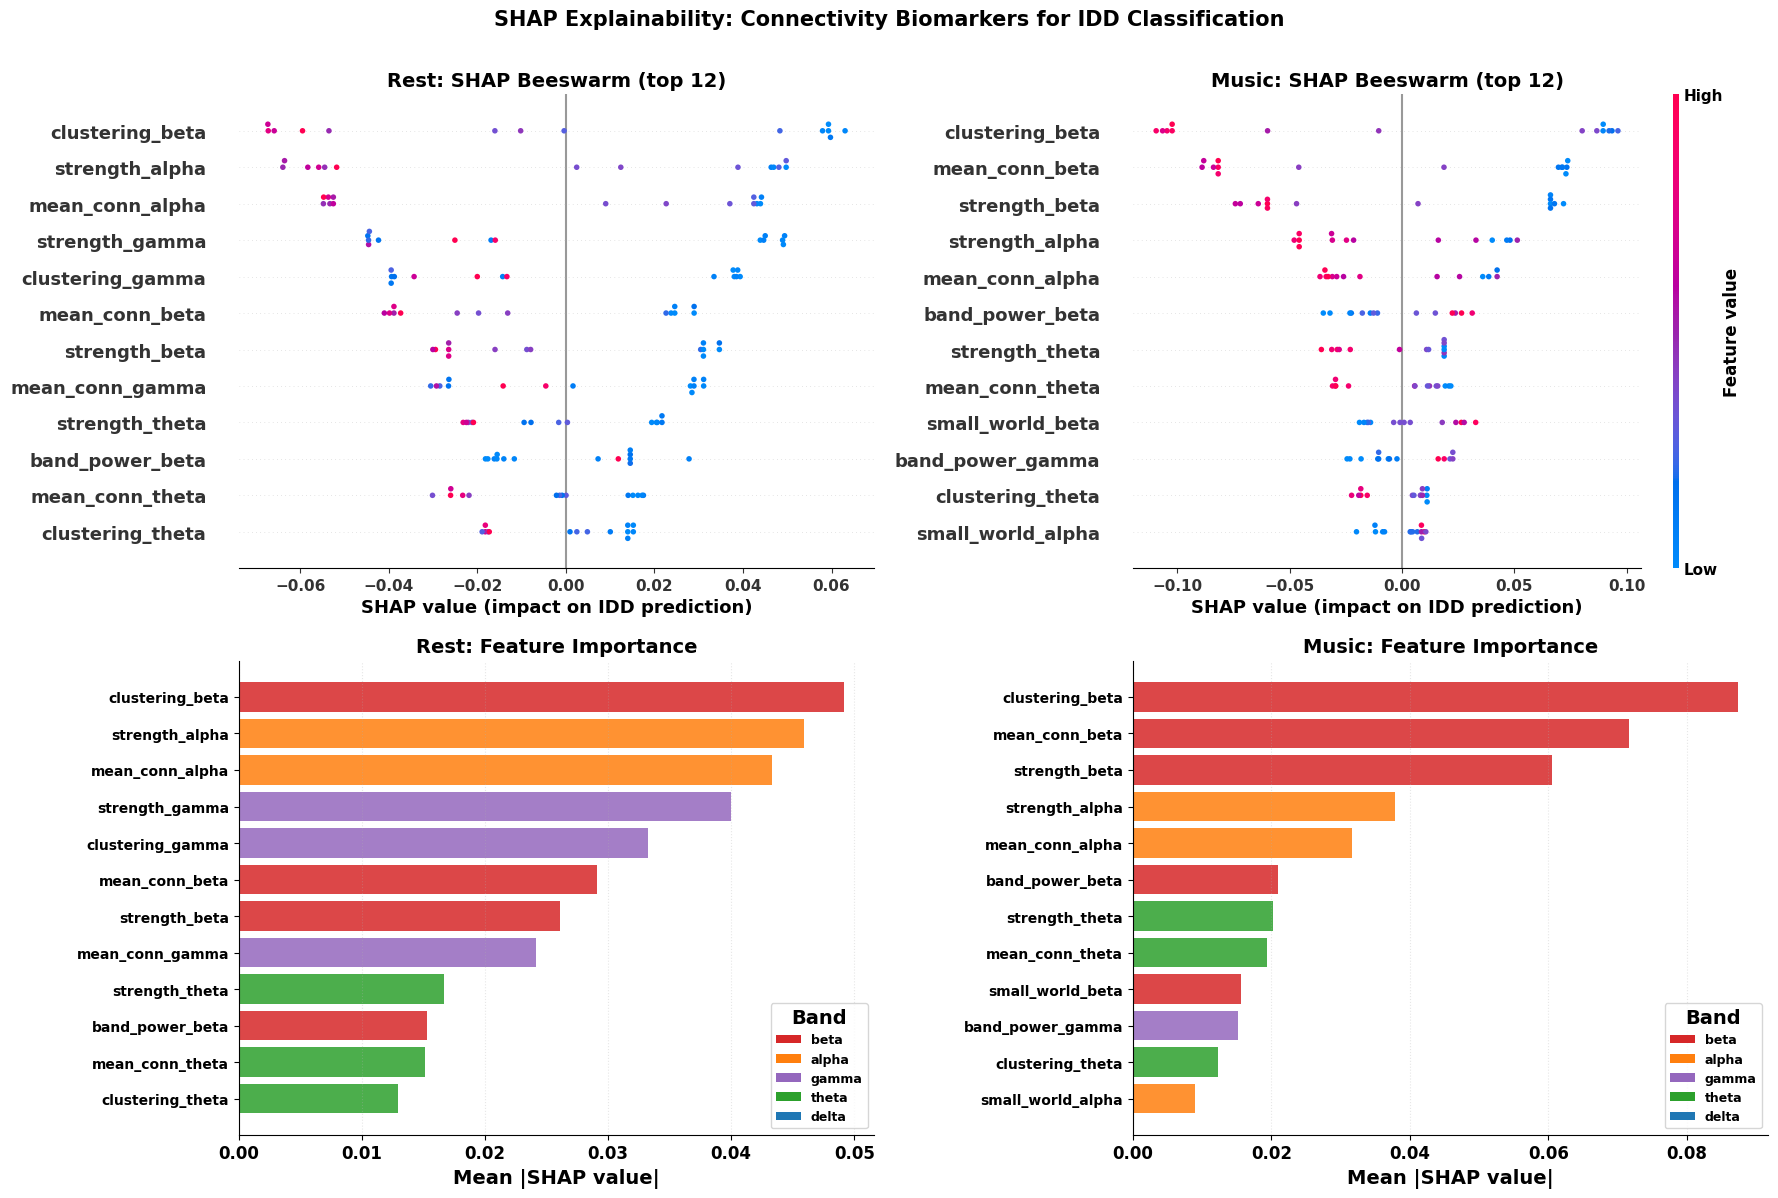

In [11]:
# Cell 4 — SHAP beeswarm + bar plots

fig = plt.figure(figsize=(18, 12))

for col, cond in enumerate(['Rest','Music']):
    sv     = shap_data[cond]['shap']
    Xs     = shap_data[cond]['X']
    fnames = shap_data[cond]['fnames']

    # ── Beeswarm (top) ───────────────────────────────────────
    ax_bee = plt.subplot(2, 2, col+1)
    plt.sca(ax_bee)
    shap.summary_plot(sv, Xs, feature_names=fnames,
                      show=False, plot_size=None, max_display=12,
                      color_bar=(col==1))
    ax_bee.set_title(f'{cond}: SHAP Beeswarm (top 12)',
                     fontsize=14, fontweight='bold')
    ax_bee.set_xlabel('SHAP value (impact on IDD prediction)')

    # ── Bar (bottom) ─────────────────────────────────────────
    ax_bar = plt.subplot(2, 2, col+3)
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)[::-1][:12]

    colors = []
    for idx in order:
        # color by band
        fn = fnames[idx]
        if   'beta'  in fn: colors.append('#d62728')
        elif 'alpha' in fn: colors.append('#ff7f0e')
        elif 'gamma' in fn: colors.append('#9467bd')
        elif 'theta' in fn: colors.append('#2ca02c')
        else:               colors.append('#1f77b4')

    y_pos = np.arange(len(order))[::-1]
    ax_bar.barh(y_pos, mean_abs[order], color=colors, alpha=0.85)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels([fnames[i] for i in order], fontsize=10)
    ax_bar.set_xlabel('Mean |SHAP value|')
    ax_bar.set_title(f'{cond}: Feature Importance',
                     fontsize=14, fontweight='bold')
    ax_bar.grid(True, axis='x', alpha=0.3, linestyle=':')

    # Band color legend
    from matplotlib.patches import Patch
    legend_el = [
        Patch(facecolor='#d62728', label='beta'),
        Patch(facecolor='#ff7f0e', label='alpha'),
        Patch(facecolor='#9467bd', label='gamma'),
        Patch(facecolor='#2ca02c', label='theta'),
        Patch(facecolor='#1f77b4', label='delta'),
    ]
    ax_bar.legend(handles=legend_el, fontsize=9,
                  loc='lower right', title='Band')

plt.suptitle('SHAP Explainability: Connectivity Biomarkers for IDD Classification',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
save_fig('fig_shap_summary.png', dpi=300)
plt.show()

Permutation testing RandomForest (500 perms, 50 trees, parallel)...

Rest:
    100/500
    200/500
    300/500
    400/500
    500/500
  Real AUC = 0.857  |  Null mean = 0.388  |  p = 0.0140

Music:
    100/500
    200/500
    300/500
    400/500
    500/500
  Real AUC = 0.878  |  Null mean = 0.382  |  p = 0.0120

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_rf_permutation.png


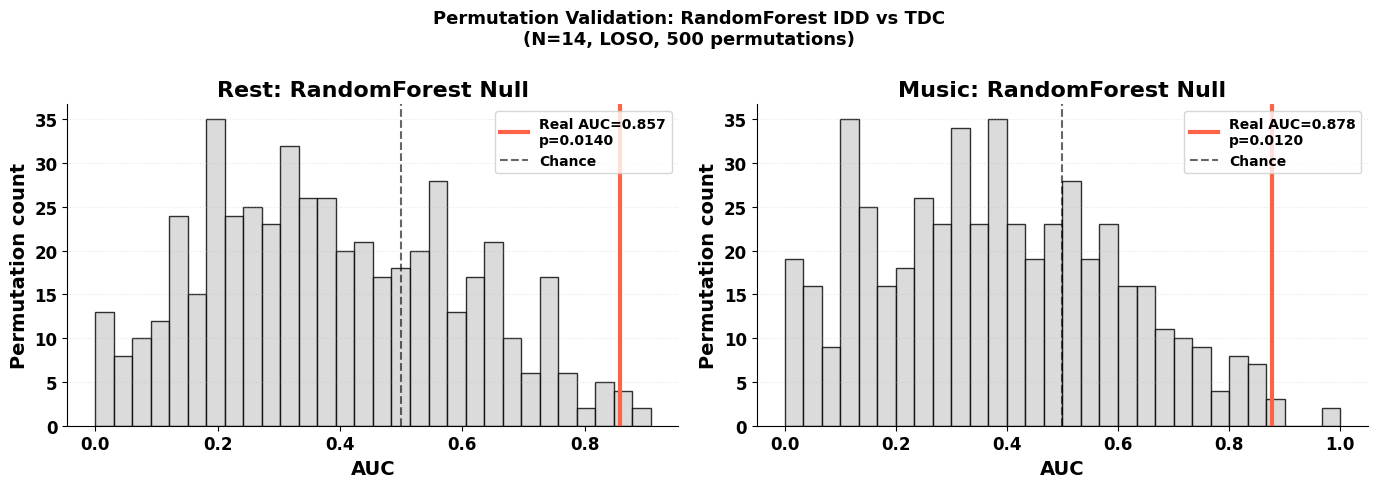

Saved ml_rf_permutation.csv


In [3]:
# Cell 5 (faster) — Permutation test, optimized

def run_loso_auc(X, y, clf_factory):
    loo = LeaveOneOut()
    y_true, y_score = [], []
    for tr, te in loo.split(X):
        scaler = StandardScaler().fit(X[tr])
        clf = clf_factory()
        clf.fit(scaler.transform(X[tr]), y[tr])
        score = clf.predict_proba(scaler.transform(X[te]))[0, 1]
        y_true.append(y[te][0]); y_score.append(score)
    return roc_auc_score(y_true, y_score)

# Lighter RF for permutation (fewer trees, parallel)
rf_fast = lambda: RandomForestClassifier(n_estimators=50, max_depth=3,
                                         random_state=42, n_jobs=-1)

def permutation_test(X, y, clf_factory, n_perm=500, seed=42):
    rng = np.random.RandomState(seed)
    real = run_loso_auc(X, y, clf_factory)
    null = np.zeros(n_perm)
    for i in range(n_perm):
        null[i] = run_loso_auc(X, rng.permutation(y), clf_factory)
        if (i+1) % 100 == 0:
            print(f"    {i+1}/{n_perm}", flush=True)
    p = (np.sum(null >= real) + 1) / (n_perm + 1)
    return real, null, p

print("Permutation testing RandomForest (500 perms, 50 trees, parallel)...\n")

perm_rf = {}
for cond in ['Rest','Music']:
    X, y, subjs, fnames = build_matrix(cond)
    print(f"{cond}:")
    real, null, p = permutation_test(X, y, rf_fast, n_perm=500)
    perm_rf[cond] = {'real':real, 'null':null, 'p':p}
    print(f"  Real AUC = {real:.3f}  |  Null mean = {null.mean():.3f}  |  p = {p:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cond in zip(axes, ['Rest','Music']):
    d = perm_rf[cond]
    ax.hist(d['null'], bins=30, color='lightgray', edgecolor='black', alpha=0.8)
    ax.axvline(d['real'], color='tomato', linewidth=3,
               label=f"Real AUC={d['real']:.3f}\np={d['p']:.4f}")
    ax.axvline(0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='Chance')
    ax.set_xlabel('AUC'); ax.set_ylabel('Permutation count')
    ax.set_title(f'{cond}: RandomForest Null')
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.suptitle('Permutation Validation: RandomForest IDD vs TDC\n(N=14, LOSO, 500 permutations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fig_rf_permutation.png', dpi=300)
plt.show()

pd.DataFrame([
    {'cond':c, 'real_AUC':perm_rf[c]['real'],
     'null_mean':perm_rf[c]['null'].mean(), 'p_perm':perm_rf[c]['p']}
    for c in ['Rest','Music']
]).to_csv(os.path.join(CSV_DIR, 'ml_rf_permutation.csv'), index=False)
print("Saved ml_rf_permutation.csv")